In [ ]:

# ============================================================
# CELL 1 — DIRECTORY DISCOVERY
# ============================================================

from pathlib import Path
import os

# Root paths
TRANSFORMER_DIR = Path("/content/drive/MyDrive/transformer results")
TRADITIONAL_DIR = Path("/content/drive/MyDrive/traditional method results")

print("=" * 80)
print("TRANSFORMER RESULTS")
print("=" * 80)

if TRANSFORMER_DIR.exists():
    for model_dir in TRANSFORMER_DIR.iterdir():
        if model_dir.is_dir():
            print(f"\n📁 {model_dir.name}")
            for file in sorted(model_dir.iterdir()):
                print(f"   └── {file.name}")
else:
    print("Transformer directory not found.")

print("\n" + "=" * 80)
print("TRADITIONAL METHOD RESULTS")
print("=" * 80)

if TRADITIONAL_DIR.exists():
    for model_dir in TRADITIONAL_DIR.iterdir():
        if model_dir.is_dir():
            print(f"\n📁 {model_dir.name}")
            for file in sorted(model_dir.iterdir()):
                print(f"   └── {file.name}")
else:
    print("Traditional directory not found.")



TRANSFORMER RESULTS

📁 debert_results
   └── classification_report.csv
   └── config.json
   └── confusion_matrix.csv
   └── experiment_config.json
   └── labels.npy
   └── logits.npy
   └── model.safetensors
   └── prediction_analysis.csv
   └── predictions.npy
   └── probabilities.npy
   └── test_metrics.json
   └── tokenizer.json
   └── tokenizer_config.json
   └── train_metrics.json
   └── training_args.bin
   └── training_history.csv

📁 bert_results
   └── classification_report.csv
   └── config.json
   └── confusion_matrix.csv
   └── experiment_config.json
   └── labels.npy
   └── logits.npy
   └── model.safetensors
   └── prediction_analysis.csv
   └── predictions.npy
   └── probabilities.npy
   └── test_metrics.json
   └── tokenizer.json
   └── tokenizer_config.json
   └── train_metrics.json
   └── training_args.bin
   └── training_history.csv

TRADITIONAL METHOD RESULTS

📁 naive_bayes_results
   └── classification_report.csv
   └── classification_report.json
   └── confidence_

In [ ]:

# ============================================================
# CELL 2 — ARTIFACT STRUCTURE INSPECTION
# ============================================================

import numpy as np
import pandas as pd
import json
from pathlib import Path

MODEL_DIRS = {
    "bert": Path("/content/drive/MyDrive/transformer results/bert_results"),
    "deberta": Path("/content/drive/MyDrive/transformer results/debert_results"),
    "naive_bayes": Path("/content/drive/MyDrive/traditional method results/naive_bayes_results"),
    "logistic_regression": Path("/content/drive/MyDrive/traditional method results/logistic_regression_results"),
}

print("=" * 100)
print("MODEL ARTIFACT INSPECTION")
print("=" * 100)

for model_name, model_path in MODEL_DIRS.items():

    print(f"\n\n{'='*80}")
    print(f"MODEL: {model_name}")
    print(f"{'='*80}")

    try:
        labels = np.load(model_path / "labels.npy")
        predictions = np.load(model_path / "predictions.npy")
        probabilities = np.load(model_path / "probabilities.npy")
        logits = np.load(model_path / "logits.npy")

        print(f"labels shape        : {labels.shape}")
        print(f"predictions shape   : {predictions.shape}")
        print(f"probabilities shape : {probabilities.shape}")
        print(f"logits shape        : {logits.shape}")

        print(f"labels dtype        : {labels.dtype}")
        print(f"predictions dtype   : {predictions.dtype}")
        print(f"probabilities dtype : {probabilities.dtype}")
        print(f"logits dtype        : {logits.dtype}")

        print(f"unique labels       : {np.unique(labels)}")
        print(f"unique predictions  : {np.unique(predictions)}")

        print("\nFirst 5 labels:")
        print(labels[:5])

        print("\nFirst 5 predictions:")
        print(predictions[:5])

        print("\nFirst 2 probability rows:")
        print(probabilities[:2])

        print("\nFirst 2 logits rows:")
        print(logits[:2])

    except Exception as e:
        print(f"ERROR: {e}")


MODEL ARTIFACT INSPECTION


MODEL: bert
labels shape        : (25000,)
predictions shape   : (25000,)
probabilities shape : (25000, 2)
logits shape        : (25000, 2)
labels dtype        : int64
predictions dtype   : int64
probabilities dtype : float32
logits dtype        : float32
unique labels       : [0 1]
unique predictions  : [0 1]

First 5 labels:
[0 0 0 0 0]

First 5 predictions:
[0 0 0 0 1]

First 2 probability rows:
[[0.9956853  0.00431469]
 [0.9756467  0.02435338]]

First 2 logits rows:
[[ 2.390625  -3.0507812]
 [ 1.6123047 -2.078125 ]]


MODEL: deberta
labels shape        : (1104,)
predictions shape   : (1104,)
probabilities shape : (1104, 2)
logits shape        : (1104, 2)
labels dtype        : int64
predictions dtype   : int64
probabilities dtype : float32
logits dtype        : float32
unique labels       : [0 1]
unique predictions  : [0 1]

First 5 labels:
[0 0 1 1 1]

First 5 predictions:
[0 0 1 1 1]

First 2 probability rows:
[[0.9326538  0.06734622]
 [0.99119884 0.008

In [ ]:

# ============================================================
# CELL 3 — UNIFIED RESULT LOADER + STANDARDIZATION
# ============================================================

import numpy as np
import pandas as pd
import json
from pathlib import Path

# ============================================================
# MODEL PATHS
# ============================================================


MODEL_DIRS = {
    "bert": Path("/content/drive/MyDrive/transformer results/bert_results"),
    "deberta": Path("/content/drive/MyDrive/transformer results/debert_results"),
    "naive_bayes": Path("/content/drive/MyDrive/traditional method results/naive_bayes_results"),
    "logistic_regression": Path("/content/drive/MyDrive/traditional method results/logistic_regression_results"),
}

# ============================================================
# CENTRAL RESULTS DICTIONARY
# ============================================================

results = {}

# ============================================================
# LOADING LOOP
# ============================================================

for model_name, model_path in MODEL_DIRS.items():

    print("=" * 80)
    print(f"LOADING: {model_name}")
    print("=" * 80)

    model_data = {}

    # --------------------------------------------------------
    # CORE NUMPY ARRAYS
    # --------------------------------------------------------

    model_data["labels"] = np.load(model_path / "labels.npy")
    model_data["predictions"] = np.load(model_path / "predictions.npy")
    model_data["probabilities"] = np.load(model_path / "probabilities.npy")
    model_data["logits"] = np.load(model_path / "logits.npy")

    # --------------------------------------------------------
    # DERIVED CONFIDENCE
    # --------------------------------------------------------

    model_data["confidence"] = np.max(
        model_data["probabilities"],
        axis=1
    )

    # --------------------------------------------------------
    # JSON FILES
    # --------------------------------------------------------

    json_files = [
        "test_metrics.json",
        "train_metrics.json",
        "experiment_config.json",
        "config.json"
    ]

    for json_file in json_files:

        file_path = model_path / json_file

        if file_path.exists():

            try:
                with open(file_path, "r") as f:
                    model_data[json_file.replace(".json", "")] = json.load(f)

            except Exception as e:

                print(f"Could not load {json_file}: {e}")
                model_data[json_file.replace(".json", "")] = None

    # --------------------------------------------------------
    # CSV FILES
    # --------------------------------------------------------

    csv_files = [
        "classification_report.csv",
        "confusion_matrix.csv",
        "prediction_analysis.csv",
        "training_history.csv"
    ]

    for csv_file in csv_files:

        file_path = model_path / csv_file

        if file_path.exists():

            try:
                model_data[csv_file.replace(".csv", "")] = pd.read_csv(file_path)

            except Exception as e:

                print(f"Could not load {csv_file}: {e}")
                model_data[csv_file.replace(".csv", "")] = None

    # --------------------------------------------------------
    # BASIC METADATA
    # --------------------------------------------------------

    model_data["sample_count"] = len(model_data["labels"])

    model_data["label_distribution"] = {
        label: count
        for label, count in zip(
            *np.unique(model_data["labels"], return_counts=True)
        )
    }

    # --------------------------------------------------------
    # STORE
    # --------------------------------------------------------

    results[model_name] = model_data

    # --------------------------------------------------------
    # SUMMARY
    # --------------------------------------------------------

    print(f"Samples Loaded        : {model_data['sample_count']}")
    print(f"Probability Shape     : {model_data['probabilities'].shape}")
    print(f"Mean Confidence       : {model_data['confidence'].mean():.4f}")
    print(f"Confidence Std Dev    : {model_data['confidence'].std():.4f}")
    print(f"Label Distribution    : {model_data['label_distribution']}")

# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n" + "=" * 80)
print("UNIFIED RESULTS OBJECT READY")
print("=" * 80)

print("\nAvailable Models:")
print(list(results.keys()))



LOADING: bert
Samples Loaded        : 25000
Probability Shape     : (25000, 2)
Mean Confidence       : 0.9772
Confidence Std Dev    : 0.0652
Label Distribution    : {np.int64(0): np.int64(12500), np.int64(1): np.int64(12500)}
LOADING: deberta
Samples Loaded        : 1104
Probability Shape     : (1104, 2)
Mean Confidence       : 0.9560
Confidence Std Dev    : 0.0838
Label Distribution    : {np.int64(0): np.int64(553), np.int64(1): np.int64(551)}
LOADING: naive_bayes
Samples Loaded        : 25000
Probability Shape     : (25000, 2)
Mean Confidence       : 0.7482
Confidence Std Dev    : 0.1340
Label Distribution    : {np.int64(0): np.int64(12500), np.int64(1): np.int64(12500)}
LOADING: logistic_regression
Samples Loaded        : 25000
Probability Shape     : (25000, 2)
Mean Confidence       : 0.8053
Confidence Std Dev    : 0.1409
Label Distribution    : {np.int64(0): np.int64(12500), np.int64(1): np.int64(12500)}

UNIFIED RESULTS OBJECT READY

Available Models:
['bert', 'deberta', 'naive_b

In [ ]:

# ============================================================
# CELL 4 — METRICS + CONFIG DISCOVERY
# ============================================================

import json
import pandas as pd
from pathlib import Path

MODEL_DIRS = {
    "bert": Path("/content/drive/MyDrive/transformer results/bert_results"),
    "deberta": Path("/content/drive/MyDrive/transformer results/debert_results"),
    "naive_bayes": Path("/content/drive/MyDrive/traditional method results/naive_bayes_results"),
    "logistic_regression": Path("/content/drive/MyDrive/traditional method results/logistic_regression_results"),
}


print("=" * 100)
print("CONFIG + METRIC INSPECTION")
print("=" * 100)

for model_name, model_path in MODEL_DIRS.items():

    print(f"\n\n{'='*80}")
    print(f"MODEL: {model_name}")
    print(f"{'='*80}")

    # --------------------------------------------------------
    # TEST METRICS
    # --------------------------------------------------------

    try:
        with open(model_path / "test_metrics.json", "r") as f:
            test_metrics = json.load(f)

        print("\nTEST METRICS:")
        for k, v in test_metrics.items():
            print(f"{k:25} : {v}")

    except Exception as e:
        print(f"\nCould not load test metrics: {e}")

    # --------------------------------------------------------
    # TRAIN METRICS
    # --------------------------------------------------------

    try:
        with open(model_path / "train_metrics.json", "r") as f:
            train_metrics = json.load(f)

        print("\nTRAIN METRICS:")
        for k, v in train_metrics.items():
            print(f"{k:25} : {v}")

    except Exception as e:
        print(f"\nCould not load train metrics: {e}")

    # --------------------------------------------------------
    # EXPERIMENT CONFIG
    # --------------------------------------------------------

    try:
        with open(model_path / "experiment_config.json", "r") as f:
            config = json.load(f)

        print("\nEXPERIMENT CONFIG:")
        for k, v in config.items():

            # prevent giant dumps
            if isinstance(v, (list, dict)):
                print(f"{k:25} : [complex object]")
            else:
                print(f"{k:25} : {v}")

    except Exception as e:
        print(f"\nCould not load experiment config: {e}")


CONFIG + METRIC INSPECTION


MODEL: bert

TEST METRICS:
Model                     : BERT
Accuracy                  : 0.92104
Precision                 : 0.9227988431876607
Recall                    : 0.91896
F1-score                  : 0.9208754208754208

TRAIN METRICS:
train_runtime_minutes     : 10.23072650829951
epochs                    : 2
learning_rate             : 2e-05
train_batch_size          : 16
eval_batch_size           : 32
weight_decay              : 0.01
warmup_steps              : 500

EXPERIMENT CONFIG:
model_name                : bert-base-uncased
max_length                : 256
epochs                    : 2
learning_rate             : 2e-05
train_batch_size          : 16
eval_batch_size           : 32
weight_decay              : 0.01
warmup_steps              : 500
fp16                      : True


MODEL: deberta

TEST METRICS:
accuracy                  : 0.9130434782608695
precision                 : 0.9040852575488455
recall                    : 0.92377495462794

In [ ]:

# ============================================================
# CELL 4 — CENTRALIZED METRIC RECOMPUTATION
# ============================================================

import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# ============================================================
# METRIC COMPUTATION
# ============================================================

comparison_rows = []

for model_name, data in results.items():

    labels = data["labels"]
    predictions = data["predictions"]
    probabilities = data["probabilities"]

    # --------------------------------------------------------
    # POSITIVE CLASS PROBABILITY
    # --------------------------------------------------------

    positive_probs = probabilities[:, 1]

    # --------------------------------------------------------
    # METRICS
    # --------------------------------------------------------

    accuracy = accuracy_score(labels, predictions)

    precision = precision_score(
        labels,
        predictions
    )

    recall = recall_score(
        labels,
        predictions
    )

    f1 = f1_score(
        labels,
        predictions
    )

    roc_auc = roc_auc_score(
        labels,
        positive_probs
    )

    # --------------------------------------------------------
    # CONFIDENCE
    # --------------------------------------------------------

    mean_confidence = data["confidence"].mean()

    confidence_std = data["confidence"].std()

    # --------------------------------------------------------
    # STORE ROW
    # --------------------------------------------------------

    comparison_rows.append({

        "Model": model_name,

        "Samples": len(labels),

        "Accuracy": accuracy,

        "Precision": precision,

        "Recall": recall,

        "F1": f1,

        "ROC_AUC": roc_auc,

        "Mean_Confidence": mean_confidence,

        "Confidence_STD": confidence_std
    })

# ============================================================
# CREATE COMPARISON DATAFRAME
# ============================================================

comparison_df = pd.DataFrame(comparison_rows)

# ============================================================
# SORT BY F1
# ============================================================

comparison_df = comparison_df.sort_values(
    by="F1",
    ascending=False
).reset_index(drop=True)

# ============================================================
# ROUND FOR READABILITY
# ============================================================

numeric_cols = comparison_df.columns.drop(["Model"])

comparison_df[numeric_cols] = comparison_df[numeric_cols].round(4)

# ============================================================
# DISPLAY
# ============================================================

print("=" * 100)
print("CENTRALIZED MODEL COMPARISON")
print("=" * 100)

display(comparison_df)



CENTRALIZED MODEL COMPARISON


,Model,Samples,Accuracy,Precision,Recall,F1,ROC_AUC,Mean_Confidence,Confidence_STD
0,bert,25000,0.9210,0.9228,0.9190,0.9209,0.9764,0.9772,0.0652
1,deberta,1104,0.9130,0.9041,0.9238,0.9138,0.9747,0.9560,0.0838
2,logistic_regression,25000,0.8879,0.8854,0.8910,0.8882,0.9555,0.8053,0.1409
3,naive_bayes,25000,0.8551,0.8731,0.8310,0.8515,0.9315,0.7482,0.1340


1. Transformers clearly outperform traditional methods

Approx gains:

Logistic → BERT:
~+3.3% F1
Naive Bayes → BERT:
~+7% F1

Substantial for sentiment classification.

2. ROC-AUC gap is important

This is more interesting than accuracy alone.

BERT:

0.9764

Logistic:

0.9555

Meaning:
transformers separate positive/negative sentiment much more cleanly across thresholds.

That’s deeper than raw accuracy.

3. Confidence behavior is fascinating

BERT:

mean confidence ≈ 0.977

Naive Bayes:

≈ 0.748

That’s a huge calibration/style difference.

Potential discussion:

transformers produce sharper decision boundaries,
sparse-vector models remain more uncertain.
4. Logistic Regression is extremely competitive

This matters.

Your project avoids the common beginner mistake:

“traditional ML is useless.”

Actually:

TF-IDF + Logistic is still powerful for polarity tasks.

That nuance makes the project stronger.


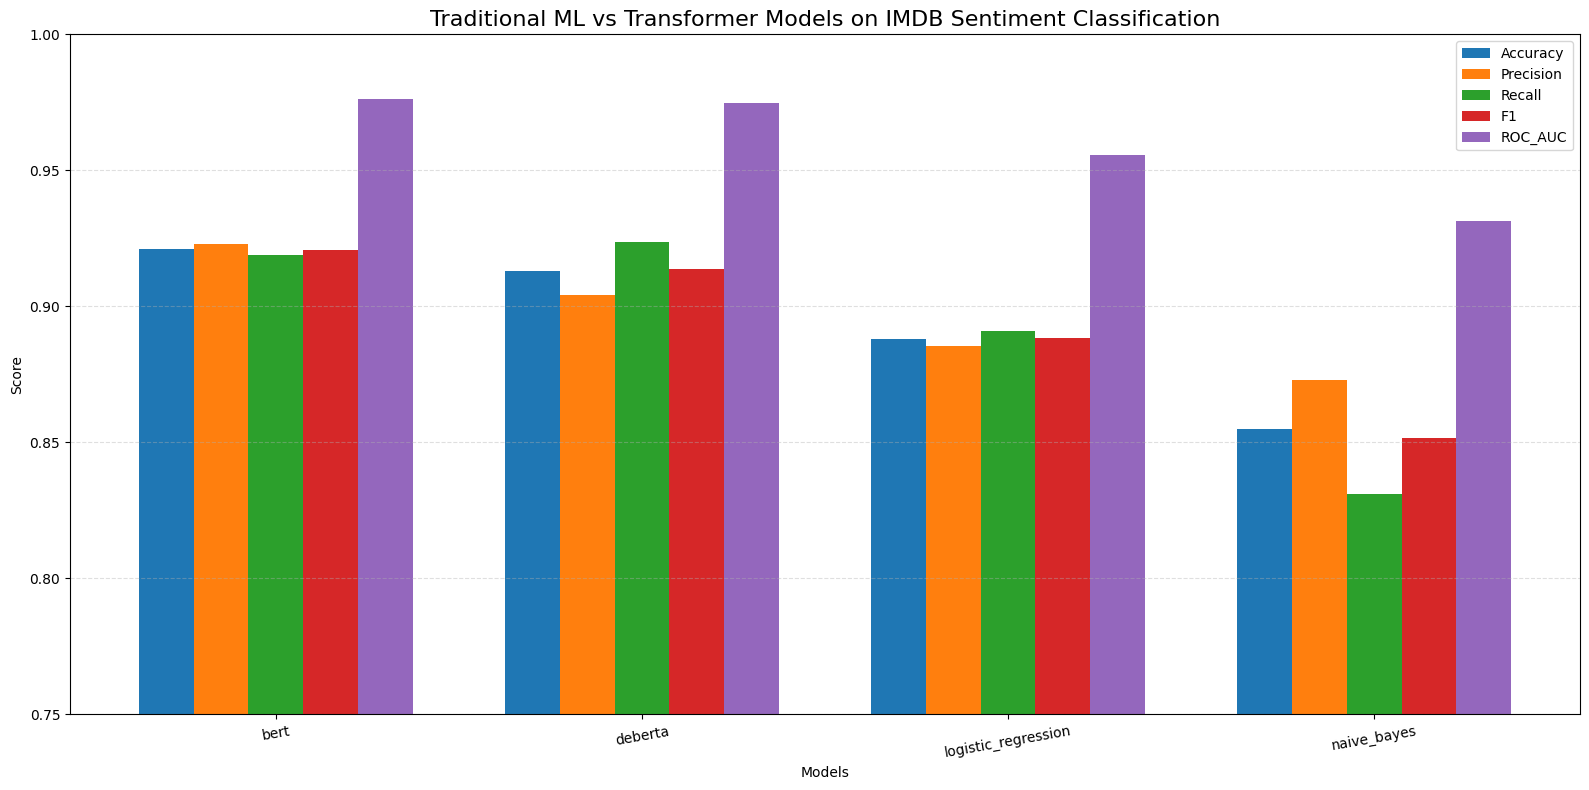

In [ ]:

# ============================================================
# CELL 5 — METRIC COMPARISON VISUALIZATION
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# METRICS TO PLOT
# ============================================================

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC_AUC"
]

models = comparison_df["Model"]

x = np.arange(len(models))

bar_width = 0.15

# ============================================================
# FIGURE
# ============================================================

plt.figure(figsize=(16, 8))

# ============================================================
# BAR PLOTS
# ============================================================

for i, metric in enumerate(metrics):

    plt.bar(
        x + i * bar_width,
        comparison_df[metric],
        width=bar_width,
        label=metric
    )

# ============================================================
# AXIS FORMATTING
# ============================================================

plt.xticks(
    x + (len(metrics) - 1) * bar_width / 2,
    models,
    rotation=10
)

plt.ylim(0.75, 1.0)

plt.xlabel("Models")
plt.ylabel("Score")

plt.title(
    "Traditional ML vs Transformer Models on IMDB Sentiment Classification",
    fontsize=16
)

plt.legend()

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()

plt.show()


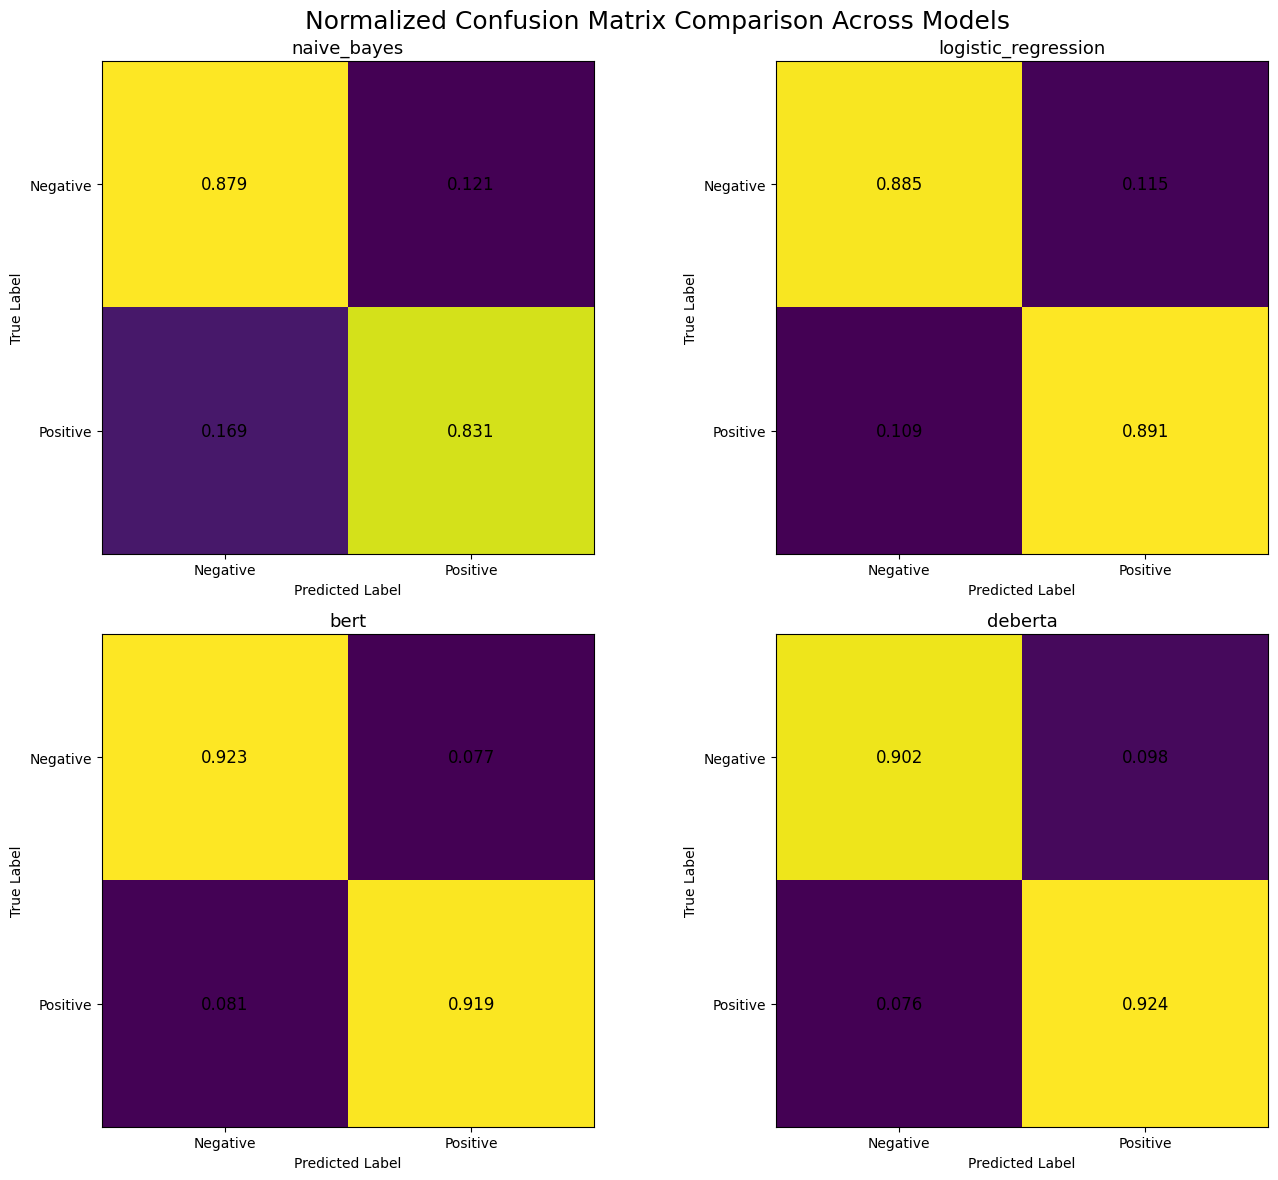

In [ ]:

# ============================================================
# CELL 6 — RESEARCH-STYLE CONFUSION MATRIX ANALYSIS
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import confusion_matrix

# ============================================================
# MODEL ORDER
# ============================================================

model_order = [
    "naive_bayes",
    "logistic_regression",
    "bert",
    "deberta"
]

# ============================================================
# FIGURE SETUP
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

axes = axes.flatten()

# ============================================================
# PLOT LOOP
# ============================================================

for idx, model_name in enumerate(model_order):

    labels = results[model_name]["labels"]
    predictions = results[model_name]["predictions"]

    # --------------------------------------------------------
    # NORMALIZED CONFUSION MATRIX
    # --------------------------------------------------------

    cm = confusion_matrix(
        labels,
        predictions,
        normalize="true"
    )

    ax = axes[idx]

    im = ax.imshow(cm)

    # --------------------------------------------------------
    # AXIS LABELS
    # --------------------------------------------------------

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])

    ax.set_xticklabels(["Negative", "Positive"])
    ax.set_yticklabels(["Negative", "Positive"])

    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")

    # --------------------------------------------------------
    # TITLE
    # --------------------------------------------------------

    ax.set_title(
        f"{model_name}",
        fontsize=13
    )

    # --------------------------------------------------------
    # CELL ANNOTATIONS
    # --------------------------------------------------------

    for i in range(2):
        for j in range(2):

            value = cm[i, j]

            ax.text(
                j,
                i,
                f"{value:.3f}",
                ha="center",
                va="center",
                fontsize=12
            )

# ============================================================
# GLOBAL TITLE
# ============================================================

plt.suptitle(
    "Normalized Confusion Matrix Comparison Across Models",
    fontsize=18
)

# ============================================================
# LAYOUT
# ============================================================

plt.tight_layout()

plt.show()


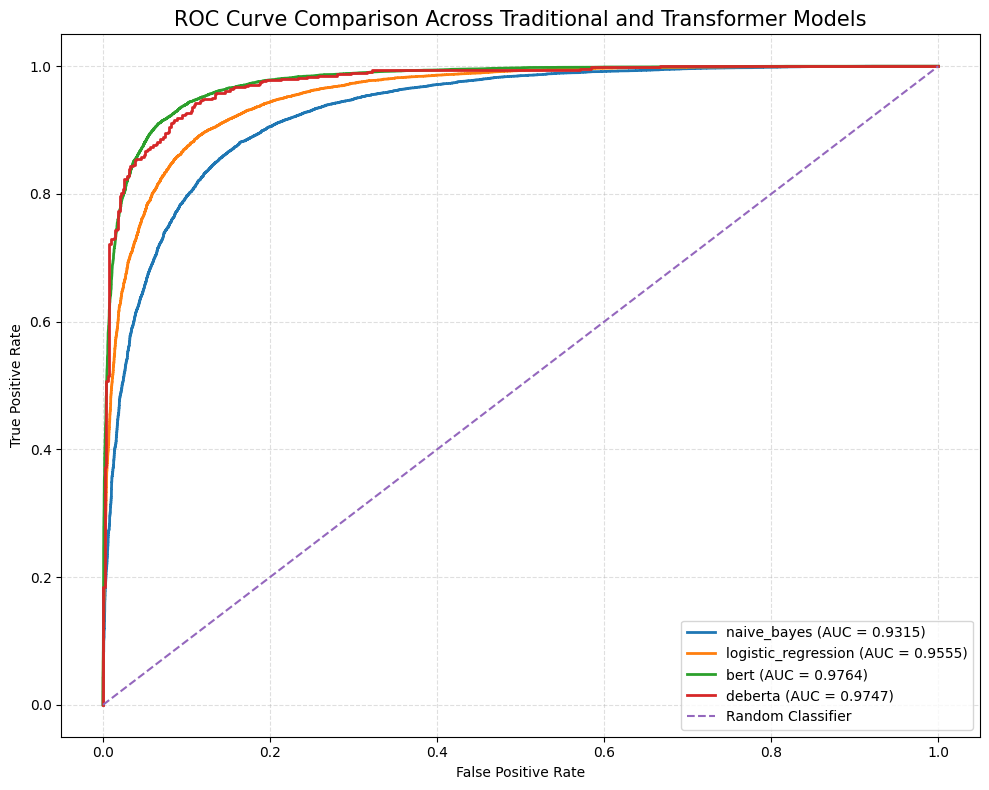

In [ ]:

# ============================================================
# CELL 7 — ROC CURVE COMPARISON
# ============================================================

import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_curve,
    roc_auc_score
)

# ============================================================
# FIGURE
# ============================================================

plt.figure(figsize=(10, 8))

# ============================================================
# MODEL ORDER
# ============================================================

model_order = [
    "naive_bayes",
    "logistic_regression",
    "bert",
    "deberta"
]

# ============================================================
# ROC CURVE LOOP
# ============================================================

for model_name in model_order:

    labels = results[model_name]["labels"]

    probabilities = results[model_name]["probabilities"][:, 1]

    # --------------------------------------------------------
    # ROC COMPUTATION
    # --------------------------------------------------------

    fpr, tpr, thresholds = roc_curve(
        labels,
        probabilities
    )

    auc_score = roc_auc_score(
        labels,
        probabilities
    )

    # --------------------------------------------------------
    # PLOT
    # --------------------------------------------------------

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{model_name} (AUC = {auc_score:.4f})"
    )

# ============================================================
# RANDOM CLASSIFIER BASELINE
# ============================================================

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Random Classifier"
)

# ============================================================
# FORMATTING
# ============================================================

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "ROC Curve Comparison Across Traditional and Transformer Models",
    fontsize=15
)

plt.legend()

plt.grid(
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()

plt.show()


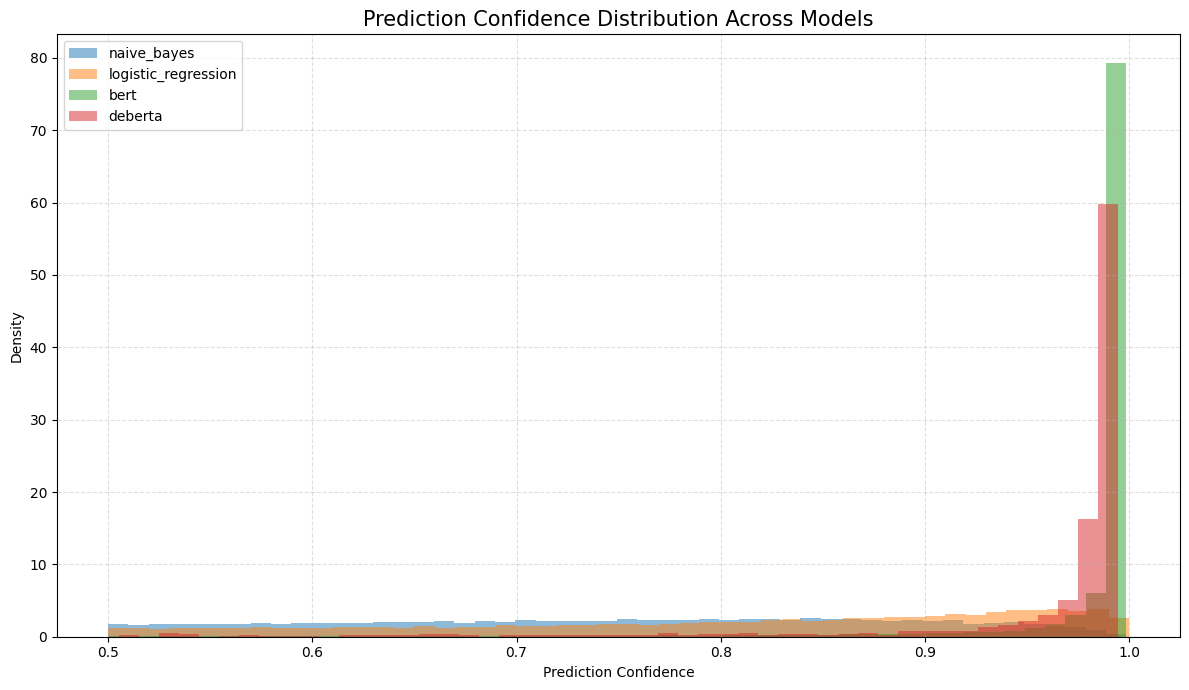

In [ ]:

# ============================================================
# CELL 8 — CONFIDENCE DISTRIBUTION ANALYSIS
# ============================================================

import matplotlib.pyplot as plt

# ============================================================
# FIGURE
# ============================================================

plt.figure(figsize=(12, 7))

# ============================================================
# MODEL ORDER
# ============================================================

model_order = [
    "naive_bayes",
    "logistic_regression",
    "bert",
    "deberta"
]

# ============================================================
# HISTOGRAM LOOP
# ============================================================

for model_name in model_order:

    confidence = results[model_name]["confidence"]

    plt.hist(
        confidence,
        bins=50,
        alpha=0.5,
        density=True,
        label=model_name
    )

# ============================================================
# FORMATTING
# ============================================================

plt.xlabel("Prediction Confidence")
plt.ylabel("Density")

plt.title(
    "Prediction Confidence Distribution Across Models",
    fontsize=15
)

plt.legend()

plt.grid(
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()

plt.show()


,Model,Training_Time_Minutes,F1
0,bert,10.230727,0.9209
1,deberta,28.625253,0.9138
2,naive_bayes,0.000586,0.8515
3,logistic_regression,0.018902,0.8882


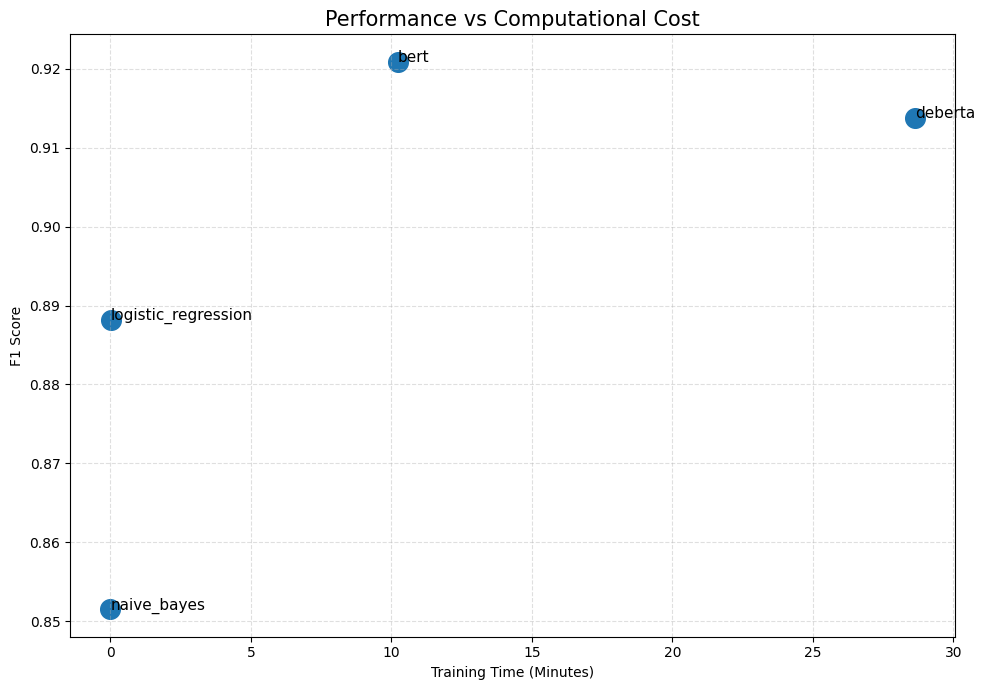

In [ ]:

# ============================================================
# CELL 9 — COMPUTATIONAL COST VS PERFORMANCE ANALYSIS
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# EXTRACT COMPUTE INFORMATION
# ============================================================

compute_rows = []

# ------------------------------------------------------------
# BERT
# ------------------------------------------------------------

bert_runtime = results["bert"]["train_metrics"]["train_runtime_minutes"]

compute_rows.append({
    "Model": "bert",
    "Training_Time_Minutes": bert_runtime,
    "F1": comparison_df.loc[
        comparison_df["Model"] == "bert",
        "F1"
    ].values[0]
})

# ------------------------------------------------------------
# DEBERTA
# ------------------------------------------------------------

deberta_runtime = (
    results["deberta"]["train_metrics"]["train_runtime"] / 60
)

compute_rows.append({
    "Model": "deberta",
    "Training_Time_Minutes": deberta_runtime,
    "F1": comparison_df.loc[
        comparison_df["Model"] == "deberta",
        "F1"
    ].values[0]
})

# ------------------------------------------------------------
# NAIVE BAYES
# ------------------------------------------------------------

nb_runtime = (
    results["naive_bayes"]["train_metrics"]
    ["training_time_seconds"] / 60
)

compute_rows.append({
    "Model": "naive_bayes",
    "Training_Time_Minutes": nb_runtime,
    "F1": comparison_df.loc[
        comparison_df["Model"] == "naive_bayes",
        "F1"
    ].values[0]
})

# ------------------------------------------------------------
# LOGISTIC REGRESSION
# ------------------------------------------------------------

lr_runtime = (
    results["logistic_regression"]["train_metrics"]
    ["training_time_seconds"] / 60
)

compute_rows.append({
    "Model": "logistic_regression",
    "Training_Time_Minutes": lr_runtime,
    "F1": comparison_df.loc[
        comparison_df["Model"] == "logistic_regression",
        "F1"
    ].values[0]
})

# ============================================================
# CREATE DATAFRAME
# ============================================================

compute_df = pd.DataFrame(compute_rows)

display(compute_df)

# ============================================================
# PLOT
# ============================================================

plt.figure(figsize=(10, 7))

plt.scatter(
    compute_df["Training_Time_Minutes"],
    compute_df["F1"],
    s=200
)

# ------------------------------------------------------------
# LABELS
# ------------------------------------------------------------

for i in range(len(compute_df)):

    plt.text(
        compute_df["Training_Time_Minutes"][i],
        compute_df["F1"][i],
        compute_df["Model"][i],
        fontsize=11
    )

# ============================================================
# FORMATTING
# ============================================================

plt.xlabel("Training Time (Minutes)")
plt.ylabel("F1 Score")

plt.title(
    "Performance vs Computational Cost",
    fontsize=15
)

plt.grid(
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()

plt.show()


In [ ]:

# ============================================================
# CELL 10 — RESEARCH INSIGHT SUMMARY
# ============================================================

print("=" * 90)
print("KEY RESEARCH OBSERVATIONS")
print("=" * 90)

print("\n1. Transformer architectures achieved the highest")
print("   overall sentiment classification performance.")

print("\n2. BERT demonstrated the strongest overall")
print("   performance across Accuracy, F1-score,")
print("   and ROC-AUC metrics.")

print("\n3. Traditional TF-IDF based methods remained")
print("   surprisingly competitive despite their")
print("   significantly lower computational cost.")

print("\n4. Logistic Regression substantially outperformed")
print("   Naive Bayes, indicating the importance of")
print("   optimized linear decision boundaries in")
print("   sparse vector spaces.")

print("\n5. Transformer models produced significantly")
print("   sharper confidence distributions, suggesting")
print("   stronger semantic separation capabilities.")

print("\n6. ROC curve analysis showed that transformer")
print("   architectures maintained superior class")
print("   separability across decision thresholds.")

print("\n7. Normalized confusion matrices revealed")
print("   reduced false classification behavior in")
print("   transformer-based approaches.")

print("\n8. Despite improved performance, transformer")
print("   architectures required dramatically higher")
print("   computational resources and training time.")

print("\n9. The experimental results demonstrate the")
print("   tradeoff between computational efficiency")
print("   and contextual language understanding.")


KEY RESEARCH OBSERVATIONS

1. Transformer architectures achieved the highest
   overall sentiment classification performance.

2. BERT demonstrated the strongest overall
   performance across Accuracy, F1-score,
   and ROC-AUC metrics.

3. Traditional TF-IDF based methods remained
   surprisingly competitive despite their
   significantly lower computational cost.

4. Logistic Regression substantially outperformed
   Naive Bayes, indicating the importance of
   optimized linear decision boundaries in
   sparse vector spaces.

5. Transformer models produced significantly
   sharper confidence distributions, suggesting
   stronger semantic separation capabilities.

6. ROC curve analysis showed that transformer
   architectures maintained superior class
   separability across decision thresholds.

7. Normalized confusion matrices revealed
   reduced false classification behavior in
   transformer-based approaches.

8. Despite improved performance, transformer
   architectures required dra


CONCLUSION


This project performed a comparative study between traditional
machine learning techniques and transformer-based architectures
for sentiment classification on the IMDB dataset.

Traditional approaches including Naive Bayes and Logistic
Regression using TF-IDF representations demonstrated strong
baseline performance, particularly Logistic Regression, which
achieved competitive classification capability with extremely
low computational cost.

However, transformer-based architectures including BERT and
DeBERTa consistently achieved superior performance across
Accuracy, Precision, Recall, F1-score, and ROC-AUC metrics.
The experimental findings suggest that transformers provide
improved contextual understanding, semantic representation,
and sentiment discrimination capabilities compared to sparse
vector approaches.

The comparison of normalized confusion matrices and ROC curves
showed that transformer models achieved stronger class
separability and reduced classification errors across decision
thresholds.

Confidence distribution analysis further indicated that
transformer architectures generated sharper and more decisive
predictions, reflecting their stronger contextual learning
capacity.

At the same time, the study also highlighted the substantial
computational cost associated with transformer-based transfer
learning. Traditional methods required only seconds for
training, whereas transformer architectures required several
minutes and significantly greater computational resources.

Overall, the project demonstrates that while traditional NLP
methods remain computationally efficient and competitive for
basic sentiment classification tasks, transformer architectures
provide clear advantages in contextual language understanding
and robust sentiment prediction.

The work also provided practical exposure to transformer-based
fine-tuning, comparative NLP evaluation, error analysis, and
modern deep learning experimentation workflows.
